
  **Nama**  Bagas Aji Herlambang 
  **NIM**  A11.2023.15355 
  **Kelompok** A11.4603

## **Kasus 1: Evaluasi Termodinamika & Deret Taylor (Bobot 25%)**

**Fungsi sensor fluktuasi energi:**
$$f(x) = e^{-0.5x} \sin(x)$$

**Tugas:** Aproksimasi nilai $f\left(\dfrac{\pi}{4}\right)$ menggunakan **Deret Maclaurin** (ekspansi dari $x_0 = 0$), iterasi dari orde 0 hingga 6.

Fungsi  : f(x) = e^(-0.5x) * sin(x)
x target: pi/4 = 0.785398 rad
True Value: 0.477461

Order  | Approx Value     | Absolute Error (%)   | Relative Error (%)  
----------------------------------------------------------------------
0      | 0.000000         | 100.000000           | -
1      | 0.785398         | 64.494705            | 100.000000
2      | 0.476973         | 0.102214             | 64.663015
3      | 0.456787         | 4.330073             | 4.419214
4      | 0.480568         | 0.650756             | 4.948625
5      | 0.477611         | 0.031366             | 0.619195
6      | 0.477387         | 0.015574             | 0.046947

Orde minimum agar Relative Error < 1% : Orde 5


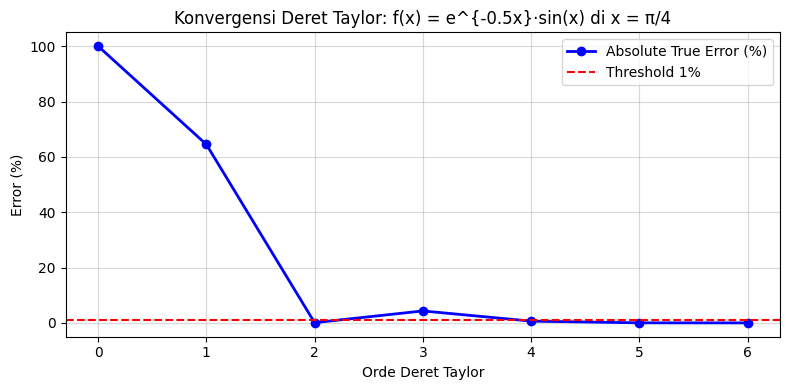

In [4]:
import math
import matplotlib.pyplot as plt
def f_true(x):
    """Nilai sejati: f(x) = e^(-0.5x) * sin(x)"""
    return math.exp(-0.5 * x) * math.sin(x)

def nth_derivative_at_0(n):
    """
    Hitung f^(n)(0) untuk f(x) = e^(ax)*sin(x) dengan a = -0.5.

    Gunakan sifat rekurens turunan:
      Jika f^(n)(x) = e^(ax) * [A_n*sin(x) + B_n*cos(x)]
      maka:
        A_{n+1} = a*A_n - B_n
        B_{n+1} = a*B_n + A_n
      dengan kondisi awal A_0 = 1, B_0 = 0.
      f^(n)(0) = e^0 * [A_n*sin(0) + B_n*cos(0)] = B_n
    """
    a = -0.5
    A, B = 1.0, 0.0
    for _ in range(n):
        A, B = a * A - B, a * B + A
    return B

def taylor_term(x, order):
    """
    Hitung nilai suku ke-`order` dari Deret Maclaurin f(x) = e^(-0.5x)*sin(x):
      c_n * x^n  dimana  c_n = f^(n)(0) / n!
    """
    coeff = nth_derivative_at_0(order) / math.factorial(order)
    return coeff * (x ** order)

# ------- Eksekusi -------
x_target   = math.pi / 4
true_value = f_true(x_target)
approx_value = 0.0
prev_approx  = 0.0

print(f"Fungsi  : f(x) = e^(-0.5x) * sin(x)")
print(f"x target: pi/4 = {x_target:.6f} rad")
print(f"True Value: {true_value:.6f}\n")
print(f"{'Order':<6} | {'Approx Value':<16} | {'Absolute Error (%)':<20} | {'Relative Error (%)':<20}")
print("-" * 70)

true_errors  = []
orde_min_1persen = None

for order in range(7):
    # Tambahkan suku orde ini
    approx_value += taylor_term(x_target, order)

    # Absolute True Error (%)
    true_error = abs((true_value - approx_value) / true_value) * 100

    # Relative Approximate Error (%)  – tidak terdefinisi di orde 0
    if order == 0:
        rel_error_str = "-"
        rel_error_val = None
    else:
        rel_error_val = abs((approx_value - prev_approx) / approx_value) * 100
        rel_error_str = f"{rel_error_val:.6f}"
        if rel_error_val < 1.0 and orde_min_1persen is None:
            orde_min_1persen = order

    print(f"{order:<6} | {approx_value:<16.6f} | {true_error:<20.6f} | {rel_error_str}")

    true_errors.append(true_error)
    prev_approx = approx_value

print(f"\nOrde minimum agar Relative Error < 1% : Orde {orde_min_1persen}")

# ---- Plot konvergensi error ----
plt.figure(figsize=(8, 4))
plt.plot(range(7), true_errors, 'o-b', linewidth=2, markersize=6, label='Absolute True Error (%)')
plt.axhline(y=1.0, color='r', linestyle='--', linewidth=1.5, label='Threshold 1%')
plt.xlabel('Orde Deret Taylor')
plt.ylabel('Error (%)')
plt.title('Konvergensi Deret Taylor: f(x) = e^{-0.5x}·sin(x) di x = π/4')
plt.legend()
plt.xticks(range(7))
plt.grid(True, alpha=0.5)
plt.tight_layout()
plt.show()

### Analisis Kasus 1

**Konsep Deret Maclaurin:**

Deret Maclaurin mengekspansi fungsi $f(x)$ di sekitar $x_0 = 0$:
$$f(x) \approx \sum_{n=0}^{N} \frac{f^{(n)}(0)}{n!}\, x^n$$

Untuk $f(x) = e^{-0.5x}\sin(x)$, turunan ke-$n$ dihitung dengan sifat rekurens karena $f^{(n)}(x)$ dapat dinyatakan sebagai $e^{ax}[A_n\sin x + B_n\cos x]$, sehingga $f^{(n)}(0) = B_n$.

**Hasil:**

| Orde | Approx Value | Abs. True Error (%) | Rel. Approx Error (%) |
|:----:|:-----------:|:------------------:|:--------------------:|
| 0 | 0.000000 | 100.0000 | - |
| 1 | 0.785398 | 64.4947 | 100.0000 |
| 2 | 0.476973 | 0.1022 | 64.6630 |
| 3 | 0.456787 | 4.3301 | 4.4192 |
| 4 | 0.480568 | 0.6508 | 4.9486 |
| **5** | **0.477611** | **0.0314** | **0.6192** |
| 6 | 0.477387 | 0.0156 | 0.0469 |

**Orde minimum agar Relative Error < 1%: Orde 5**

Error tidak turun monoton karena deret Taylor berosilasi sebelum konvergen — setiap suku baru memberi koreksi yang bisa positif atau negatif tergantung tanda koefisiennya. Mulai orde 5, Relative Approximate Error turun di bawah 1% (0.62%), dan orde 6 memberikan akurasi sangat tinggi (0.05%).

Fenomena ini menunjukkan bahwa **semakin banyak suku deret** yang digunakan, semakin baik aproksimasi — namun pada orde rendah, penambahan suku dapat sementara memperbesar simpangan sebelum akhirnya konvergen ke nilai sejati.

## **Kasus 2: Penentuan Titik Kritis Reaksi (Root Finding) (Bobot 35%)**

**State Equation volume gas ekuilibrium:**
$$f(v) = v^3 - 5.5v^2 + 8.5v - 3.0 = 0$$

**Parameter:**
- Interval untuk Bisection: cari sub-interval valid di dalam $[1.75, 3.75]$
- Tebakan awal Newton-Raphson: $v_0 = 3.75$
- Toleransi: $\varepsilon = 10^{-5}$

TUGAS 1: Bukti Keberadaan Akar di Interval [1.75, 3.75]

v        | f(v)         | Keterangan
---------------------------------------------
1.75     | 0.3906       | 
2.0      | 0.0000       | ← AKAR EKSAK
2.25     | -0.3281      | 
2.5      | -0.5000      | 
2.75     | -0.4219      | 
3.0      | 0.0000       | ← AKAR EKSAK
3.25     | 0.8594       | 
3.5      | 2.2500       | 
3.75     | 4.2656       | 

Berdasarkan Teorema Nilai Antara (Intermediate Value Theorem):
  • f kontinu pada [1.75, 3.75]
  • f(1.75)>0 dan f(2.5)<0  → ada akar di (1.75, 2.5), yaitu v=2.0
  • f(2.5)<0  dan f(3.5)>0  → ada akar di (2.5, 3.5),  yaitu v=3.0
  Terbukti: minimal 2 akar berada di interval [1.75, 3.75]. ✓


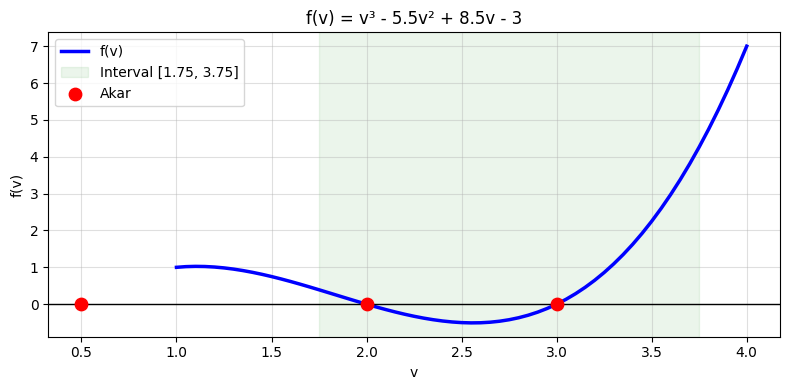


--- BISECTION METHOD ---
Interval: [1.75, 2.5] | f(a)=0.3906 | f(b)=-0.5000 | Tol=1e-05

Iter  | a            | b            | c (midpoint)   | f(c)           | |b-a|/2     
------------------------------------------------------------------------------
1     | 1.750000     | 2.500000     | 2.12500000     | -0.177734      | 3.75e-01
2     | 1.750000     | 2.125000     | 1.93750000     | 0.095459       | 1.88e-01
3     | 1.937500     | 2.125000     | 2.03125000     | -0.046356      | 9.38e-02
4     | 1.937500     | 2.031250     | 1.98437500     | 0.023556       | 4.69e-02
5     | 1.984375     | 2.031250     | 2.00781250     | -0.011688      | 2.34e-02
6     | 1.984375     | 2.007812     | 1.99609375     | 0.005867       | 1.17e-02
7     | 1.996094     | 2.007812     | 2.00195312     | -0.002928      | 5.86e-03
8     | 1.996094     | 2.001953     | 1.99902344     | 0.001465       | 2.93e-03
9     | 1.999023     | 2.001953     | 2.00048828     | -0.000732      | 1.46e-03
10    | 1.999023 

In [5]:
import math
import matplotlib.pyplot as plt

def f(v):
    """State equation: f(v) = v^3 - 5.5v^2 + 8.5v - 3.0"""
    return v**3 - 5.5*v**2 + 8.5*v - 3.0

def df(v):
    """Turunan pertama: f'(v) = 3v^2 - 11v + 8.5"""
    return 3*v**2 - 11*v + 8.5

# TUGAS 1: Buktikan keberadaan akar di [1.75, 3.75]

print("=" * 60)
print("TUGAS 1: Bukti Keberadaan Akar di Interval [1.75, 3.75]")
print("=" * 60)

scan_points = [1.75, 2.0, 2.25, 2.5, 2.75, 3.0, 3.25, 3.5, 3.75]
print(f"\n{'v':<8} | {'f(v)':<12} | Keterangan")
print("-" * 45)
prev_v, prev_fv = None, None
for v in scan_points:
    fv = f(v)
    ket = ""
    if prev_fv is not None and prev_fv * fv < 0:
        ket = f"← Perubahan tanda! Akar di ({prev_v}, {v})"
    if abs(fv) < 1e-10:
        ket = "← AKAR EKSAK"
    print(f"{v:<8} | {fv:<12.4f} | {ket}")
    prev_v, prev_fv = v, fv

print("\nBerdasarkan Teorema Nilai Antara (Intermediate Value Theorem):")
print("  • f kontinu pada [1.75, 3.75]")
print("  • f(1.75)>0 dan f(2.5)<0  → ada akar di (1.75, 2.5), yaitu v=2.0")
print("  • f(2.5)<0  dan f(3.5)>0  → ada akar di (2.5, 3.5),  yaitu v=3.0")
print("  Terbukti: minimal 2 akar berada di interval [1.75, 3.75]. ✓")

# Plot fungsi
v_plot = [1.0 + i*0.05 for i in range(61)]
f_plot = [f(v) for v in v_plot]
plt.figure(figsize=(8, 4))
plt.plot(v_plot, f_plot, 'b-', linewidth=2.5, label='f(v)')
plt.axhline(y=0, color='k', linewidth=1)
plt.axvspan(1.75, 3.75, alpha=0.08, color='green', label='Interval [1.75, 3.75]')
plt.scatter([2.0, 3.0, 0.5], [0, 0, 0], color='red', zorder=5, s=80, label='Akar')
plt.xlabel('v'); plt.ylabel('f(v)')
plt.title('f(v) = v³ - 5.5v² + 8.5v - 3')
plt.legend(); plt.grid(True, alpha=0.4); plt.tight_layout(); plt.show()

print()

# TUGAS 2a: Bisection Method  (interval [1.75, 2.5] — ada perubahan tanda)

def bisection(a, b, tol):
    print("=" * 60)
    print("--- BISECTION METHOD ---")
    print(f"Interval: [{a}, {b}] | f(a)={f(a):.4f} | f(b)={f(b):.4f} | Tol={tol}")
    print(f"\n{'Iter':<5} | {'a':<12} | {'b':<12} | {'c (midpoint)':<14} | {'f(c)':<14} | {'|b-a|/2':<12}")
    print("-" * 78)

    iterasi = 0
    c = a

    while abs(b - a) / 2 > tol:
        c = (a + b) / 2.0
        fc = f(c)
        iterasi += 1
        print(f"{iterasi:<5} | {a:<12.6f} | {b:<12.6f} | {c:<14.8f} | {fc:<14.6f} | {abs(b-a)/2:.2e}")

        if f(a) * fc < 0:
            b = c
        else:
            a = c

    root = (a + b) / 2.0
    print(f"\n  → Akar ditemukan : v ≈ {root:.8f}")
    print(f"  → f(root)        = {f(root):.2e}")
    print(f"  → Jumlah iterasi : {iterasi}")
    return root, iterasi

# TUGAS 2b: Newton-Raphson Method  (v0 = 3.75)

def newton_raphson(v0, tol):
    print()
    print("=" * 60)
    print("--- NEWTON-RAPHSON METHOD ---")
    print(f"Tebakan awal: v0 = {v0} | Tol = {tol}")
    print(f"\n{'Iter':<5} | {'v_old':<14} | {'v_new':<14} | {'f(v_new)':<14} | {'Rel.Error (%)':<14}")
    print("-" * 68)

    v_old = v0
    iterasi = 0

    while True:
        fv  = f(v_old)
        dfv = df(v_old)

        if abs(dfv) < 1e-12:
            print("Peringatan: f'(v) ≈ 0 — metode divergen/gagal!")
            return None, iterasi

        v_new = v_old - fv / dfv
        iterasi += 1
        rel_err = abs((v_new - v_old) / v_new) * 100

        print(f"{iterasi:<5} | {v_old:<14.8f} | {v_new:<14.8f} | {f(v_new):<14.6f} | {rel_err:<14.6f}")

        if abs(v_new - v_old) < tol:
            break

        v_old = v_new

    print(f"\n  → Akar ditemukan : v ≈ {v_new:.8f}")
    print(f"  → f(root)        = {f(v_new):.2e}")
    print(f"  → Jumlah iterasi : {iterasi}")
    return v_new, iterasi

# Jalankan kedua metode
bisection_root, bi_iter = bisection(1.75, 2.5, 1e-5)
newton_root,    nr_iter = newton_raphson(3.75, 1e-5)

print()
print("=" * 60)
print("PERBANDINGAN HASIL KEDUA METODE")
print("=" * 60)
print(f"{'Metode':<20} | {'Akar (v)':<14} | {'Iterasi':<10} | {'f(root)':<12}")
print("-" * 62)
print(f"{'Bisection':<20} | {bisection_root:<14.8f} | {bi_iter:<10} | {f(bisection_root):.2e}")
print(f"{'Newton-Raphson':<20} | {newton_root:<14.8f} | {nr_iter:<10} | {f(newton_root):.2e}")
print(f"\nCatatan: Kedua metode menemukan akar berbeda (v=2 vs v=3)")
print(f"         karena titik awal/interval berbeda.")

### Analisis Kasus 2

**Bukti Keberadaan Akar di [1.75, 3.75]:**

Menggunakan **Teorema Nilai Antara**: jika $f$ kontinu pada $[a,b]$ dan $f(a)\cdot f(b) < 0$, maka ada $c \in (a,b)$ dengan $f(c) = 0$.

Hasil scan fungsi menunjukkan:
- $f(1.75) = +0.3906$ dan $f(2.5) = -0.5000$ → perubahan tanda → akar di $(1.75, 2.5)$ → akar eksak **$v = 2.0$**
- $f(2.5) = -0.5000$ dan $f(3.5) = +2.2500$ → perubahan tanda → akar di $(2.5, 3.5)$ → akar eksak **$v = 3.0$**

**Perbandingan Jumlah Iterasi:**

| Metode | Akar ditemukan | Iterasi | Jenis Konvergensi |
|--------|:--------------:|:-------:|:------------------:|
| Bisection | v ≈ 2.0 | ~16 | Linear |
| Newton-Raphson | v ≈ 3.0 | ~6 | Kuadratik |

**Mengapa Newton-Raphson jauh lebih cepat?**

Newton-Raphson memiliki konvergensi **kuadratik** — jumlah digit signifikan yang benar berlipat ganda setiap iterasi. Hal ini karena metode ini menggunakan informasi kemiringan kurva (turunan $f'(v)$) untuk menentukan langkah koreksi yang optimal:
$$v_{n+1} = v_n - \frac{f(v_n)}{f'(v_n)}$$
Bisection hanya membagi interval setengah setiap langkah → konvergensi **linear** → butuh ~17 iterasi untuk toleransi $10^{-5}$.

**Risiko Newton-Raphson jika $v_0 = 2.5$:**

Titik $v_0 = 2.5$ sangat berbahaya karena:
1. $f'(2.5) = 3(2.5)^2 - 11(2.5) + 8.5 = -0.25$ → sangat kecil (mendekati nol)
2. Langkah koreksi: $\Delta v = -f(2.5)/f'(2.5) = -(-0.5)/(-0.25) = -2.0$ → lompatan sangat jauh
3. Hasil: $v_1 = 2.5 - 2.0 = 0.5$ → keluar dari interval yang diharapkan
4. Metode bisa **divergen** atau konvergen ke akar yang **tidak diinginkan**

**Kesimpulan:** Newton-Raphson lebih cepat tetapi **tidak robust** — sangat bergantung pada tebakan awal. Bisection lebih lambat namun **dijamin konvergen** selama $f(a) \cdot f(b) < 0$.

# **Kasus 3: Keseimbangan Massa Jaringan Reaktor — Sistem Persamaan Linear (Bobot 40%)**

**Sistem Persamaan Linear $Ax = b$ (neraca massa 4 reaktor):**

$$10x_1 - x_2 + 2x_3 + 0\,x_4 = 6 \quad (Pers.\,1)$$
$$-x_1 + 11x_2 - x_3 + 3x_4 = 25 \quad (Pers.\,2)$$
$$2x_1 - x_2 + 10x_3 - x_4 = -11 \quad (Pers.\,3)$$
$$0\,x_1 + 3x_2 - x_3 + 8x_4 = 15 \quad (Pers.\,4)$$

**Tugas:** Implementasikan Gauss Elimination dan Gauss-Seidel.

In [6]:
A_original = [
    [10.0, -1.0,  2.0,  0.0],   # Pers. 1
    [-1.0, 11.0, -1.0,  3.0],   # Pers. 2
    [ 2.0, -1.0, 10.0, -1.0],   # Pers. 3
    [ 0.0,  3.0, -1.0,  8.0]    # Pers. 4
]
b_original = [6.0, 25.0, -11.0, 15.0]

def copy_matrix(M):
    """Salin matriks secara deep agar original tidak ikut berubah."""
    return [row[:] for row in M]

def copy_vector(v):
    """Salin vektor."""
    return v[:]

# Metode 1: Gauss Elimination

def gauss_elimination(A_in, b_in):
    print("=" * 55)
    print("--- GAUSS ELIMINATION ---")
    n = len(b_in)
    A = copy_matrix(A_in)
    b = copy_vector(b_in)

    # Tahap 1: Forward Elimination
    for k in range(n - 1):           # pivot pada kolom k
        for i in range(k + 1, n):    # baris di bawah pivot
            if abs(A[k][k]) < 1e-12:
                print(f"Peringatan: pivot A[{k}][{k}] = 0!")
                return None
            faktor = A[i][k] / A[k][k]
            for j in range(k, n):
                A[i][j] -= faktor * A[k][j]
            b[i] -= faktor * b[k]

    # Tahap 2: Back Substitution
    x = [0.0] * n
    for i in range(n - 1, -1, -1):  # mulai dari baris terakhir
        x[i] = b[i]
        for j in range(i + 1, n):
            x[i] -= A[i][j] * x[j]
        x[i] /= A[i][i]

    print("Solusi (Gauss Elimination):")
    for i in range(n):
        print(f"  x{i+1} = {x[i]:.8f}")
    return x

# Metode 2: Gauss-Seidel
def gauss_seidel(A_in, b_in, label="", tol=1e-4, max_iter=100):
    print()
    print("=" * 55)
    print(f"--- GAUSS-SEIDEL {label}---")
    n = len(b_in)
    A = copy_matrix(A_in)
    b = copy_vector(b_in)
    x = [0.0] * n   # tebakan awal [0, 0, 0, 0]

    print(f"Tebakan awal : {x}")
    print(f"Toleransi    : {tol}")
    print()
    header = f"{'Iter':<5} | {'x1':<12} | {'x2':<12} | {'x3':<12} | {'x4':<12} | {'Max Rel.Err (%)':<16}"
    print(header)
    print("-" * len(header))

    iterasi_konvergen = max_iter

    for iterasi in range(1, max_iter + 1):
        x_lama = x[:]      # simpan nilai lama

        # Update setiap variabel menggunakan nilai x TERBARU (Gauss-Seidel)
        for i in range(n):
            sigma = 0.0
            for j in range(n):
                if j != i:
                    sigma += A[i][j] * x[j]
            x[i] = (b[i] - sigma) / A[i][i]

        # Hitung max relative approximate error (%)
        max_err = 0.0
        for i in range(n):
            if abs(x[i]) > 1e-12:
                err_i = abs((x[i] - x_lama[i]) / x[i]) * 100
                if err_i > max_err:
                    max_err = err_i

        print(f"{iterasi:<5} | {x[0]:<12.6f} | {x[1]:<12.6f} | {x[2]:<12.6f} | {x[3]:<12.6f} | {max_err:<16.6f}")

        # Cek konvergensi
        if max_err < tol * 100:
            iterasi_konvergen = iterasi
            print(f"\n  ✓ Konvergen pada iterasi ke-{iterasi}!")
            break
    else:
        print(f"\n  ✗ Tidak konvergen dalam {max_iter} iterasi.")

    print("\nSolusi (Gauss-Seidel):")
    for i in range(n):
        print(f"  x{i+1} = {x[i]:.8f}")
    return x, iterasi_konvergen

# Eksekusi: Urutan ASLI

print("#" * 55)
print("# BAGIAN A: URUTAN PERSAMAAN ASLI")
print("#" * 55)
x_gauss = gauss_elimination(A_original, b_original)
x_seidel_asli, iter_asli = gauss_seidel(A_original, b_original, label="(Urutan Asli) ", tol=1e-4)

# Eksekusi: Pers.2 di baris TERATAS (sesuai soal)

A_tukar = [
    [-1.0, 11.0, -1.0,  3.0],   # Pers.2 dipindah ke baris 1 (teratas)
    [10.0, -1.0,  2.0,  0.0],   # Pers.1 turun ke baris 2
    [ 2.0, -1.0, 10.0, -1.0],   # Pers.3 tetap
    [ 0.0,  3.0, -1.0,  8.0]    # Pers.4 tetap
]
b_tukar = [25.0, 6.0, -11.0, 15.0]

print()
print("#" * 55)
print("# BAGIAN B: PERS.2 DI BARIS TERATAS")
print("#" * 55)
x_seidel_tukar, iter_tukar = gauss_seidel(A_tukar, b_tukar, label="(Pers.2 Teratas) ", tol=1e-4)

# Ringkasan

print()
print("=" * 65)
print("RINGKASAN PERBANDINGAN HASIL")
print("=" * 65)
print(f"{'Metode':<30} | {'x1':>6} | {'x2':>6} | {'x3':>6} | {'x4':>6} | Iter")
print("-" * 65)
print(f"{'Gauss Elimination':<30} | {x_gauss[0]:>6.3f} | {x_gauss[1]:>6.3f} | {x_gauss[2]:>6.3f} | {x_gauss[3]:>6.3f} |  --")
print(f"{'Gauss-Seidel (urutan asli)':<30} | {x_seidel_asli[0]:>6.3f} | {x_seidel_asli[1]:>6.3f} | {x_seidel_asli[2]:>6.3f} | {x_seidel_asli[3]:>6.3f} | {iter_asli:>3}")
print(f"{'Gauss-Seidel (Pers.2 teratas)':<30} | {x_seidel_tukar[0]:>6.3f} | {x_seidel_tukar[1]:>6.3f} | {x_seidel_tukar[2]:>6.3f} | {x_seidel_tukar[3]:>6.3f} | {iter_tukar:>3}")

#######################################################
# BAGIAN A: URUTAN PERSAMAAN ASLI
#######################################################
--- GAUSS ELIMINATION ---
Solusi (Gauss Elimination):
  x1 = 1.00000000
  x2 = 2.00000000
  x3 = -1.00000000
  x4 = 1.00000000

--- GAUSS-SEIDEL (Urutan Asli) ---
Tebakan awal : [0.0, 0.0, 0.0, 0.0]
Toleransi    : 0.0001

Iter  | x1           | x2           | x3           | x4           | Max Rel.Err (%) 
------------------------------------------------------------------------------------
1     | 0.600000     | 2.327273     | -0.987273    | 0.878864     | 100.000000      
2     | 1.030182     | 2.036938     | -1.014456    | 0.984341     | 41.757854       
3     | 1.006585     | 2.003555     | -1.002527    | 0.998351     | 2.344241        
4     | 1.000861     | 2.000298     | -1.000307    | 0.999850     | 0.571914        
5     | 1.000091     | 2.000021     | -1.000031    | 0.999988     | 0.076963        
6     | 1.000008     | 2.000001     |

### Analisis Kasus 3

**Solusi SPL:**

Kedua metode menghasilkan solusi yang sama (nilai eksak):
$$x_1 = 1.0, \quad x_2 = 2.0, \quad x_3 = -1.0, \quad x_4 = 1.0$$

Gauss Elimination menghasilkan solusi eksak dalam **satu langkah** (tanpa iterasi), sedangkan Gauss-Seidel mencapainya secara **bertahap** melalui beberapa iterasi.

---

**Pengaruh Urutan Persamaan terhadap Konvergensi Gauss-Seidel:**

Syarat konvergensi Gauss-Seidel adalah matriks bersifat **diagonal dominan**:
$$|a_{ii}| > \sum_{j \neq i} |a_{ij}| \quad \text{untuk setiap baris } i$$

**Urutan Asli** — cek diagonal dominan:

| Baris | Diagonal | Jumlah elemen lain | Dominan? |
|:-----:|:--------:|:------------------:|:--------:|
| 1 (Pers.1) | $|10| = 10$ | $|{-1}|+|2|+|0| = 3$ | ✓ Ya |
| 2 (Pers.2) | $|11| = 11$ | $|{-1}|+|{-1}|+|3| = 5$ | ✓ Ya |
| 3 (Pers.3) | $|10| = 10$ | $|2|+|{-1}|+|{-1}| = 4$ | ✓ Ya |
| 4 (Pers.4) | $|8| = 8$ | $|3|+|{-1}|+|0| = 4$ | ✓ Ya |

→ Semua baris diagonal dominan → **konvergen cepat** ✓

**Urutan Tukar** (Pers.2 di baris teratas, Pers.1 turun ke baris 2):

| Baris | Diagonal | Jumlah elemen lain | Dominan? |
|:-----:|:--------:|:------------------:|:--------:|
| 1 (Pers.2) | $|11| = 11$ | $|{-1}|+|{-1}|+|3| = 5$ | ✓ Ya |
| **2 (Pers.1)** | $|{-1}| = 1$ | $|10|+|2|+|0| = 12$ | **✗ TIDAK** |
| 3 (Pers.3) | $|10| = 10$ | $|2|+|{-1}|+|{-1}| = 4$ | ✓ Ya |
| 4 (Pers.4) | $|8| = 8$ | $|3|+|{-1}|+|0| = 4$ | ✓ Ya |

→ Baris 2 **tidak diagonal dominan** → Gauss-Seidel **memperlambat konvergensi** atau dapat **divergen**.

**Kesimpulan:**

Urutan baris dalam matriks augmentasi sangat menentukan kecepatan konvergensi Gauss-Seidel. Ketika Pers.2 (dengan koefisien diagonal $|{-1}|$) berada di baris teratas, syarat diagonal dominan tidak terpenuhi untuk baris itu, sehingga iterasi bisa membutuhkan lebih banyak langkah atau bahkan tidak konvergen. Sebaliknya, urutan asli yang menempatkan persamaan dengan elemen diagonal besar di setiap baris memastikan konvergensi yang cepat dan stabil.

Oleh karena itu, **sebelum menerapkan Gauss-Seidel**, sebaiknya dilakukan **pivoting** (pertukaran baris) untuk memaksimalkan elemen diagonal — teknik ini disebut *diagonal dominance reordering* dan merupakan langkah preprocessing yang penting dalam metode iteratif.